## Advanced Statistics - Mixed Models 4: GLMM 



<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Zero-Inflated Models in R

### Table of contents

1. Zero-Inflated Model
    * Why Zero-Inflated Models?
    * Type of Zero-Inflated Models?
    * Quick Visual: Excess Zeros (R)
    * GLMMTMB: How to Specify Zero Inflation
2. Example: Owl Nestlings begging.
     * The data set Nestlings Owls:
3. Import data and diagnostics:
     * Data import and changing names:
     * Point 1: Data summary.
     * Point 1: Visualisation I.
     * Point 1: Visualisation II
     * Point 1: Visualisation III.
     * Point 1: Visualisation IV.
4. Zip/ZINB model specification.
     * ZIP and ZINB in GLMMTMB:
5. Model diagnostics.
      * DHARMA analysis QQPlot:
      * DHARMA analysis residual quartiles Plot:
      * Influencial points:
6. ZIPNB model statistics.
     * Model comparison AIC and Log Likelihood:
     * Model Output:
     * Model simplification:
     * Model Output: Random effect table
     * Model Output: Conditional model
     * Model Output: Zero-Inflation model
     * Final visualisation:
     * BUT


<div class="alert alert-block alert-info" style="margin-top: 20px">

## 1. Zero-Inflated Model
    
### Why Zero-Inflated Models?
* Many count datasets show __more zeros__ than a Poisson/NegBin would predict.
* Two ways a zero can appear:
	 1. __Structural zero:__ outcome is not possible e.g., process of interest not present.
	 2. __Sampling zero:__ outcome could occur but happened to be zero by chance.
      
### Type of Zero-Inflated Models?
__Zero-inflated model__ idea (ZIP / ZINB):

* A __mixture:__
	 * With probability π_i (logit-linked), the process is a certain zero.
	 * Otherwise (probability 1-π_i), the count comes from Poisson/NegBin with mean $μ_i=exp(X_i β)$.

* Running two models at once:
	 * __Count Model__ (conditional model): log link for $μ_i$.
	 * __Zero-Inflation Model__ (ZI model): logit link for $π_i$.

Both models conditional and $ZI$, contain their own interpretation and information!!!

Closely related but different: __Hurdle models__

— separate a zero/non-zero hurdle from a truncated count model.

### Quick Visual: Excess Zeros (R)
Below we’ll

(a) look at a count histogram and

(b) compare the __observed zero rate__ to what a plain Poisson GLM would predict.

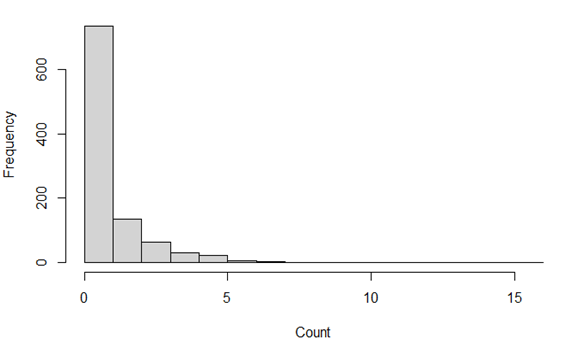

Observed counts with excess zeros.

### glmmTMB: How to Specify Zero Inflation
__Formula parts__
__* Conditional (count) model:__ count ~ predictors + (1|random_effect)
   * Link: __log__ ($μ_i$=exp($η_i$ )).
     
__* Zero-inflation model:__ ziformula = ~predictors_for_structural_zero
   * Link: __logit__ for ($π_i$=P("structural zero" ).

__* Family:__ poisson, nbinom1, or nbinom2




In [1]:
# Install glmmTMB (install only once)
# install.packages("glmmTMB")

In [2]:
# Load the package
library(glmmTMB)

# Load example dataset
dat <- glmmTMB::Owls
head(dat)

,Nest,FoodTreatment,SexParent,ArrivalTime,SiblingNegotiation,BroodSize,NegPerChick,logBroodSize
,<fct>,<fct>,<fct>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,AutavauxTV,Deprived,Male,22.25,4,5,0.8,1.609438
2,AutavauxTV,Satiated,Male,22.38,0,5,0.0,1.609438
3,AutavauxTV,Deprived,Male,22.53,2,5,0.4,1.609438
4,AutavauxTV,Deprived,Male,22.56,2,5,0.4,1.609438
5,AutavauxTV,Deprived,Male,22.61,2,5,0.4,1.609438
6,AutavauxTV,Deprived,Male,22.65,2,5,0.4,1.609438


In [3]:
names(dat)   # check available variables

[1] "Nest"               "FoodTreatment"      "SexParent"         
[4] "ArrivalTime"        "SiblingNegotiation" "BroodSize"         
[7] "NegPerChick"        "logBroodSize"

In [4]:
str(dat)   # check variable names

'data.frame':	599 obs. of  8 variables:
 $ Nest              : Factor w/ 27 levels "AutavauxTV","Bochet",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ FoodTreatment     : Factor w/ 2 levels "Deprived","Satiated": 1 2 1 1 1 1 1 2 1 2 ...
 $ SexParent         : Factor w/ 2 levels "Female","Male": 2 2 2 2 2 2 2 1 2 1 ...
 $ ArrivalTime       : num  22.2 22.4 22.5 22.6 22.6 ...
 $ SiblingNegotiation: int  4 0 2 2 2 2 18 4 18 0 ...
 $ BroodSize         : int  5 5 5 5 5 5 5 5 5 5 ...
 $ NegPerChick       : num  0.8 0 0.4 0.4 0.4 0.4 3.6 0.8 3.6 0 ...
 $ logBroodSize      : num  1.61 1.61 1.61 1.61 1.61 ...


#### Fit a Zero-inflated Poisson model code using `glmmTMB` with random intercept

In [5]:
# Fit a Zero-inflated Poisson model
# - Response: SiblingNegotiation (count outcome)  -> Response: count
# - Predictors: FoodTreatment + ArrivalTime        -> Predictors: x1 + x2
# - Random intercept: (1 | Nest)                   -> Random intercept: (1 | group)
# - Zero-inflation: modeled by SexParent           -> Zero-inflation: modeled by z1 + z2
# - (use ~0 for no zero-inflation, ~1 for intercept-only)
# - Family: Poisson

fit_zip <- glmmTMB(
  SiblingNegotiation ~ FoodTreatment + ArrivalTime + (1 | Nest),
  ziformula = ~ SexParent,
  family = poisson,
  data = dat
)

- The `ziformula` controls the zero-inflation part:
- `~01` → no zero-inflation
- `~1` → intercept-only zero-inflation
- `~ predictors` → zero-inflation modeled by predictors.



- __Response variable:__ `SiblingNegotiation` is the count variable in Owls
- __Predictors:__ Use real predictors like `FoodTreatment` and `ArrivalTime` instead of x1, x2.
- __Random effect:__ The grouping variable is `Nest` (group).
- __Zero-inflation predictor:__ `SexParent` is available, (not z1/z2)



- __Zero-inflation formula:__ `ziformula = ~ ~ SexParent` means the probability of extra zeros is modeled by predictors `z1` and `z2`.
- __Random intercept:__ `(1 | Nest)` accounts for group-level variability.
- __Family choice:__ Poisson is the baseline count distribution; you can later compare with Negative Binomial if overdispersion is suspected.


In [6]:
# Inspect results
# summary(fit_zip)

#### Fit a Zero-inflated Negative Binomial code using `glmmTMB` with random intercept (often better with overdispersion)

In [7]:
# Step 3: Fit a Zero-inflated Negative Binomial model
# - Response: SiblingNegotiations (count outcome)      -> Response: count
# - Predictors: FoodTreatment + ArrivalTime            -> Predictors: x1 + x2
# - Random intercept: (1 | Nest)                       -> Random intercept: (1 | group)
# - Zero-inflation: modeled by SexParent               -> Zero-inflation: modeled by z1
# - Family: Negative Binomial (nbinom1)                -> nbinom1 handles overdispersion better than Poisson)

fit_zinb <- glmmTMB(
  SiblingNegotiation ~ FoodTreatment + ArrivalTime + (1 | Nest),
  ziformula = ~ SexParent,
  family = nbinom1,
  data = dat
)

- __Response variable:__ `SiblingNegotiation` is the count variable in Owls, not count.
- __Predictors:__ Use `FoodTreatment` and `ArrivalTime` instead of x1, x2.
- __Random effect:__ The grouping variable is `Nest`, not group.
- __Zero-inflation predictor:__ Use SexParent instead of z1.



- Zero-inflation formula: `ziformula = ~ SexParent` means zero-inflation probability depends on predictor `SexParent`.

- Family choice: `nbinom1` is often better when variance grows linearly with the mean (overdispersion).


In [8]:
# Inspect results
# summary(fit_zinb)

__Interpretation__
* Conditional coefficients (log link): same intepretation as poisson GLM.
* ZI coefficients (logit link): effects on odds of a structural zero.
* Model diagnostics in similar fashion.
* Compare models with AIC.


## 2. Example: Owl Nestlings begging.
### The data set Nestlings Owls:

#### The owl dataset:
Nestling begging behaviour may be an honest signal of need used by parents to adjust optimally both feeding rate and within-brood food allocation. Although several studies showed that mothers and fathers can be differentially responsive to nestling begging behaviour with one parent showing a stronger tendency to feed the offspring that beg the most, little information is yet available on whether offspring beg for food at different intensities from the mother than father. The same nests are measured repeatedly, the nest is used as a random effect.

From: Nestling barn owls beg more intensely in the presence of their mother than in the presence of their father, ALEXANDRE ROULIN & LOUIS-FELIX BERSIER; ANIMAL BEHAVIOUR, 2007, 74.

The Owls data set is a data frame with 599 observations on the following variables:
* __SiblingNegotiation:__ Response variable, a numeric vector.
* __SexParent:__ (Factor of interest), sex of provisioning parent: Female or Male.
* __ArrivalTime:__ a numeric vector in minutes during the night (nomalized?).
* __FoodTreatment:__ (factor) food treatment: Deprived or Satiated
* __Nest:__ a random factor describing individual nest locations
* __BroodSize:__ brood size.
* __NegPerChick:__ number of negotations per chick.


## 3. Import data and diagnostics:
__Data import and changing names:__


In [9]:
# Load the package
library(glmmTMB)   # Provides the Owls dataset and modeling functions

# Load the dataset
Owls <- glmmTMB::Owls

# Create shorter variable names
Owls <- transform(
  Owls,
  NCalls = SiblingNegotiation,   # Rename SiblingNegotiation → NCalls
  FT     = FoodTreatment         # Rename FoodTreatment → FT
)

- __Stepwise clarity:__ Each block has a clear purpose (load package, load data, rename, explore).
- __Transform usage:__ `transform()` is used to create shorter aliases without losing the original variables.
- __Exploration:__ `str()` shows the internal structure, while `summary()` gives descriptive statistics.


In [10]:
# Explore the dataset structure
str(Owls)        # Check variable types and structure

'data.frame':	599 obs. of  10 variables:
 $ Nest              : Factor w/ 27 levels "AutavauxTV","Bochet",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ FoodTreatment     : Factor w/ 2 levels "Deprived","Satiated": 1 2 1 1 1 1 1 2 1 2 ...
 $ SexParent         : Factor w/ 2 levels "Female","Male": 2 2 2 2 2 2 2 1 2 1 ...
 $ ArrivalTime       : num  22.2 22.4 22.5 22.6 22.6 ...
 $ SiblingNegotiation: int  4 0 2 2 2 2 18 4 18 0 ...
 $ BroodSize         : int  5 5 5 5 5 5 5 5 5 5 ...
 $ NegPerChick       : num  0.8 0 0.4 0.4 0.4 0.4 3.6 0.8 3.6 0 ...
 $ logBroodSize      : num  1.61 1.61 1.61 1.61 1.61 ...
 $ NCalls            : int  4 0 2 2 2 2 18 4 18 0 ...
 $ FT                : Factor w/ 2 levels "Deprived","Satiated": 1 2 1 1 1 1 1 2 1 2 ...


In [11]:
summary(Owls)    # Get summary statistics

          Nest      FoodTreatment  SexParent    ArrivalTime   
 Oleyes     : 52   Deprived:320   Female:245   Min.   :21.71  
 Montet     : 41   Satiated:279   Male  :354   1st Qu.:23.11  
 Etrabloz   : 34                               Median :24.38  
 Yvonnand   : 34                               Mean   :24.76  
 Champmartin: 30                               3rd Qu.:26.25  
 Lucens     : 29                               Max.   :29.25  
 (Other)    :379                                              
 SiblingNegotiation   BroodSize      NegPerChick     logBroodSize  
 Min.   : 0.00      Min.   :1.000   Min.   :0.000   Min.   :0.000  
 1st Qu.: 0.00      1st Qu.:4.000   1st Qu.:0.000   1st Qu.:1.386  
 Median : 5.00      Median :4.000   Median :1.200   Median :1.386  
 Mean   : 6.72      Mean   :4.392   Mean   :1.564   Mean   :1.439  
 3rd Qu.:11.00      3rd Qu.:5.000   3rd Qu.:2.500   3rd Qu.:1.609  
 Max.   :32.00      Max.   :7.000   Max.   :8.500   Max.   :1.946  
                    

Things to note:

1. Median and maximum in NCalls are far apart relative to zero.
2. It is not a balanced design judging from the factors; not a problem if no ANOVA table is constructed.


### Point 1: Data summary.

How many zero’s are there relative to the number of observations?

__Table:__


In [54]:
# Load required package
library(dplyr)

# Step 2: Load the dataset
Owls <- glmmTMB::Owls

# Step 3: Summarize zeros relative to total observations
Owls %>%
  summarize(
    n_total   = n(),                                # total number of rows
    n_zero    = sum(SiblingNegotiation == 0),       # count of zeros
    prop_zero = mean(SiblingNegotiation == 0)       # proportion of zeros
  )

n_total,n_zero,prop_zero
<int>,<int>,<dbl>
599,156,0.2604341


__Explanation:__
- `n_total`: total number of observations in the dataset.
- `n_zero`: number of rows where `SiblingNegotiation` equals zero.
- `prop_zero`: proportion of zeros relative to the total sample size.


### Point 1: Visualisation I.

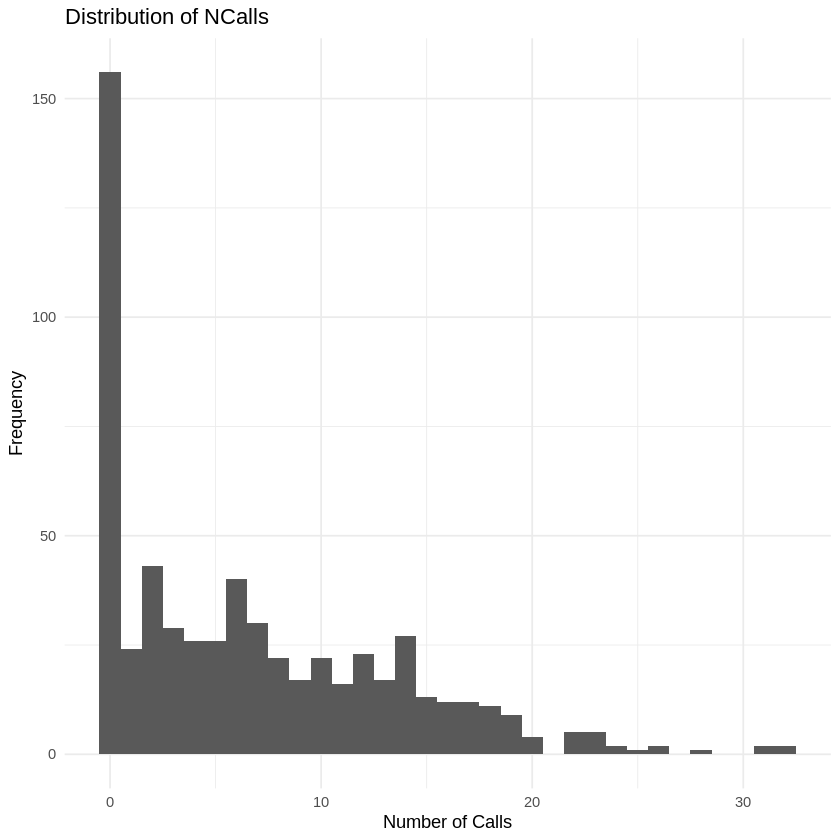

In [13]:
# Load required package
library(ggplot2)

# Load dataset
Owls <- glmmTMB::Owls

# Create shorter variable name (correct spelling)
Owls <- transform(
  Owls,
  NCalls = SiblingNegotiation   # note the plural form
)

# Plot histogram of NCalls
ggplot(Owls, aes(x = NCalls)) +
  geom_histogram(
    binwidth = 1,        # width of each bin
    boundary = -0.5,     # align bins with integer counts
    closed = "left"      # include left boundary in bin
  ) +
  labs(
    title = "Distribution of NCalls",
    x = "Number of Calls",
    y = "Frequency"
  ) +
  theme_minimal()


Note: Give the high peak at Calls are 0, zero-inflation is realistic problem.

### Point 1: Visualisation II
__Number of zero’s by groups (FT, SexParent)__


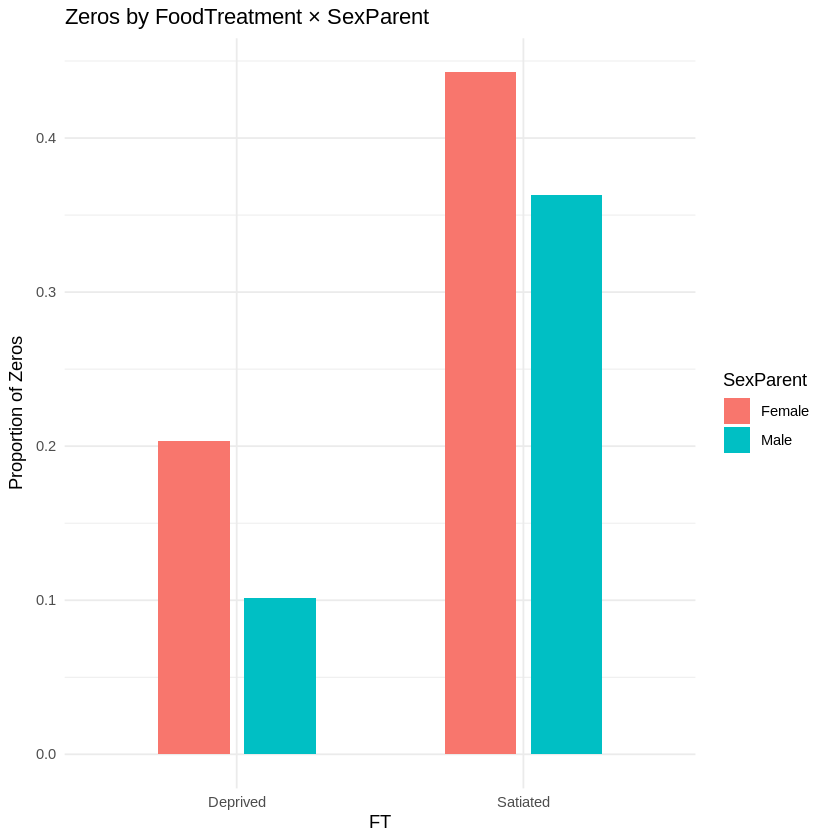

In [14]:
# Load required packages
library(dplyr)
library(ggplot2)

# Load dataset and create shorter variable names
Owls <- glmmTMB::Owls
Owls <- transform(
  Owls,
  NCalls = SiblingNegotiation,   # rename count variable
  FT     = FoodTreatment          # shorten FoodTreatment
)

# Summarize proportion of zeros by FT × SexParent
zero_summary <- Owls %>%
  group_by(FT, SexParent) %>%
  summarize(
    prop_zero = mean(NCalls == 0),   # proportion of zeros
    .groups   = "drop"
  )

# Visualize results
ggplot(zero_summary, aes(x = FT, y = prop_zero, fill = SexParent)) +
  geom_col(
    position = position_dodge(width = 0.6),
    width    = 0.5
  ) +
  labs(
    y     = "Proportion of Zeros",
    title = "Zeros by FoodTreatment × SexParent"
  ) +
  theme_minimal()


Note: There is a clear difference between deprived and saturated, less so for SexParents.

### Point 1: Visualisation III

`geom_smooth()` using formula = 'y ~ x'


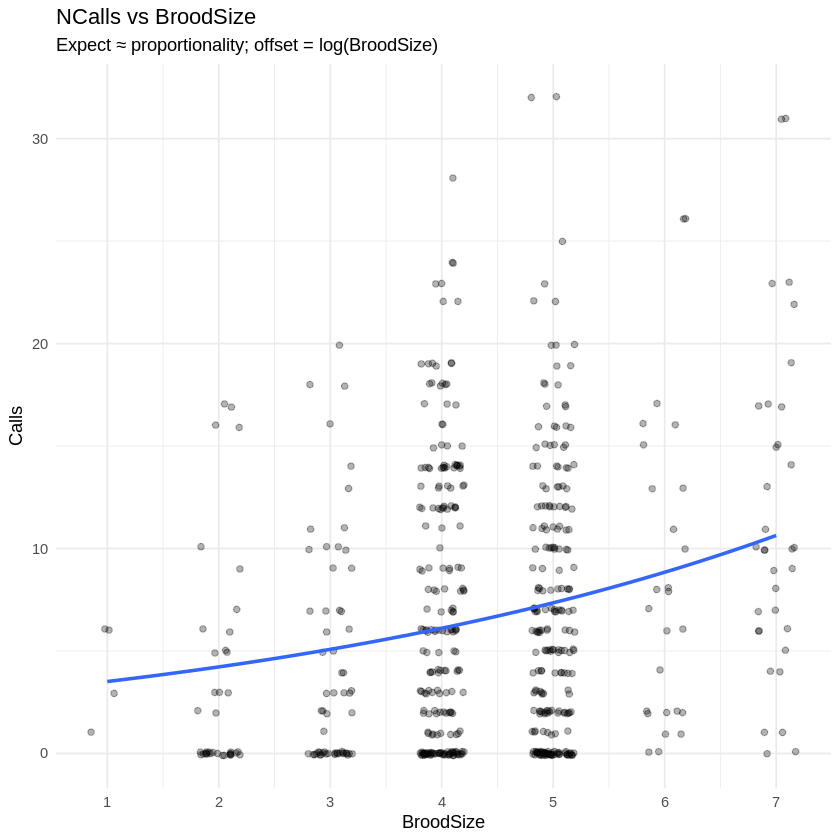

In [15]:
# Plot NCalls vs BroodSize
ggplot(Owls, aes(x = BroodSize, y = NCalls)) +
  geom_jitter(
    width  = 0.2,   # horizontal jitter
    height = 0.1,   # vertical jitter
    alpha  = 0.3    # transparency for overlapping points
  ) +
  geom_smooth(
    method      = "glm",
    method.args = list(family = poisson),
    se          = FALSE
  ) +
  scale_x_continuous(breaks = scales::pretty_breaks()) +
  labs(
    title    = "NCalls vs BroodSize",
    subtitle = "Expect ≈ proportionality; offset = log(BroodSize)",
    x        = "BroodSize",
    y        = "Calls"
  ) +
  theme_minimal()


Note: Blue line connects the means. Brood size 2 till 5 show zero-inflation 6 and 7 do not (have higher more realistic means because of that).

### Point 1: Visualisation IV

`geom_smooth()` using formula = 'y ~ x'


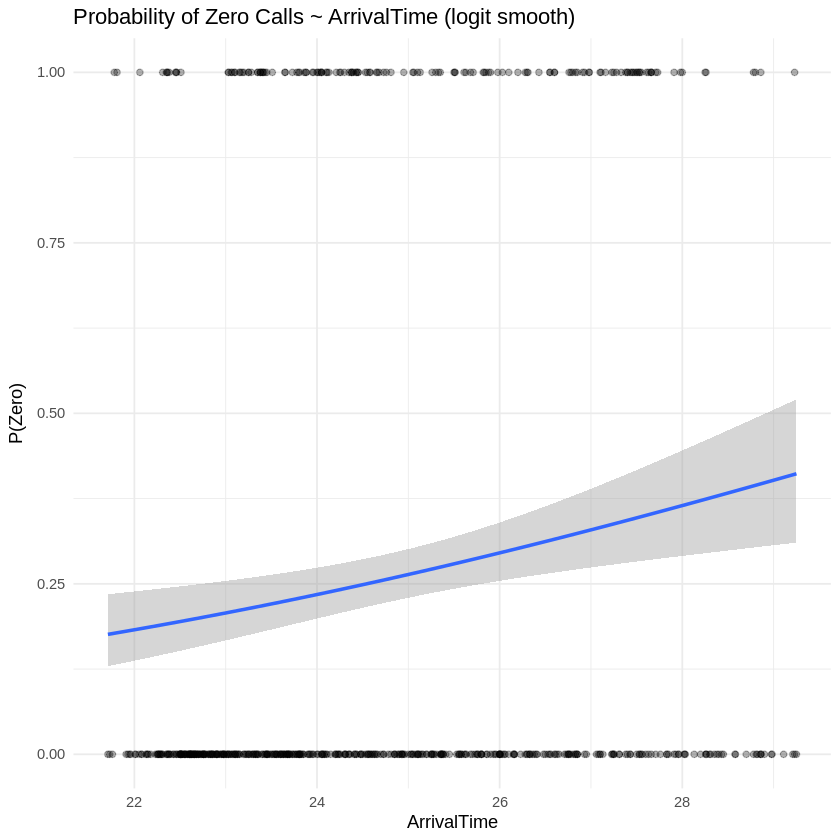

In [16]:
# Add indicator for zero counts
Owls <- Owls %>%
  mutate(is_zero = NCalls == 0)

# Plot probability of zero calls vs ArrivalTime
ggplot(Owls, aes(x = ArrivalTime, y = as.numeric(is_zero))) +
  geom_point(alpha = 0.3) +
  geom_smooth(
    method      = "glm",
    method.args = list(family = binomial),
    se          = TRUE
  ) +
  labs(
    y     = "P(Zero)",
    title = "Probability of Zero Calls ~ ArrivalTime (logit smooth)"
  ) +
  theme_minimal()


## 4. Zip/ZINB model specification.
### ZIP and ZINB in glmmTMB:


In [17]:
# Fit models
## Normal GLMM (no zero-inflation)
Normal_GLM <- glmmTMB(
  NCalls ~ (FT + ArrivalTime) * SexParent +
    offset(log(BroodSize)) + (1 | Nest),
  data       = Owls,
  ziformula  = ~0,
  family     = poisson
)


In [18]:
## ZIP with single zero-inflation parameter applying to all observations (intercept only)
ZIP_Intercept <- glmmTMB(
  NCalls ~ (FT + ArrivalTime) * SexParent +
    offset(log(BroodSize)) + (1 | Nest),
  data       = Owls,
  ziformula  = ~1,
  family     = poisson
)


In [19]:
## ZIP with more complex zero-inflation model
# ZIP using a more complicated model for zero inflation based on plots
ZIP_Model <- glmmTMB(
  NCalls ~ (FT + ArrivalTime) * SexParent +
    offset(log(BroodSize)) + (1 | Nest),
  data       = Owls,
  ziformula  = ~1 + ArrivalTime * FT + SexParent,
  family     = poisson
)


In [20]:
## ZINB models with different link functions
ZINB_Model2 <- update(ZIP_Model, family = nbinom2)
ZINB_Model1 <- update(ZIP_Model, family = nbinom1)


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”


In [21]:
## ZINB model with BroodSize as covariate (not offset)
ZINB_Model1_COV <- update(
  ZINB_Model1,
  . ~ (FT + ArrivalTime) * SexParent + BroodSize + (1 | Nest)
)


In [22]:
# Inspect results
#summary(Normal_GLM)
#summary(ZIP_Intercept)
#summary(ZIP_Model)
#summary(ZINB_Model1)
#summary(ZINB_Model2)
#summary(ZINB_Model1_COV)


__Note:__ Using link function nbinom2 gives a convergence problem. Difference between nbinom1 and nbinom2

In __glmmTMB__, both are negative binomial families, but they differ in the variance–mean relationship.

Variance Functions
* __nbinom1__

   $Var(Y)=μ+αμ$

   → Variance increases linearly with the mean.

* __nbinom2__ (default)

    $Var(Y)=μ+αμ^2$

   → Variance increases quadratically with the mean.


When to Use Which?
* Use __nbinom1__ when variance grows roughly in proportion to the mean.
* Use __nbinom2__ when variance grows faster than the mean (curving upward).

Next we need to do the data diagnostics. I will select only three.


## 5. Model diagnostics.
### DHARMA analysis QQPlot:


In [23]:
# Install DHARMa (install only once)
# install.packages("DHARMa")

In [24]:
# Load required package
library(DHARMa)

# Simulate residuals for each fitted model
SimDat1 <- simulateResiduals(ZIP_Intercept, plot = FALSE)
SimDat2 <- simulateResiduals(ZIP_Model, plot = FALSE)
SimDat3 <- simulateResiduals(ZINB_Model1, plot = FALSE)
SimDat4 <- simulateResiduals(ZINB_Model1_COV, plot = FALSE)


This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')



DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details



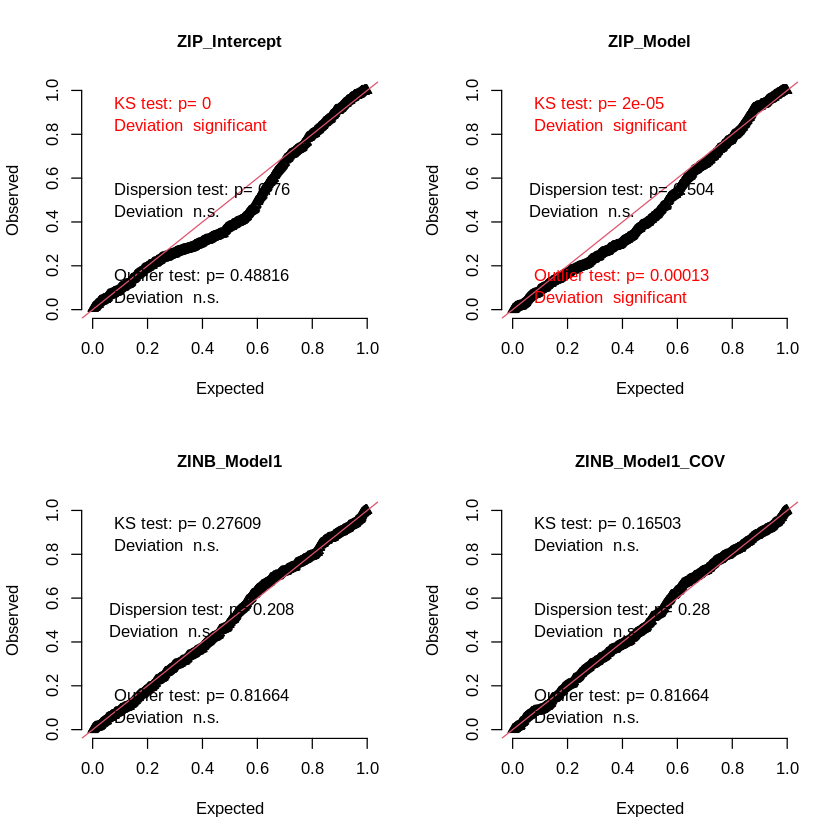

In [25]:
# Set plotting layout (2 rows × 2 columns)
par(mfrow = c(2, 2))

# Plot QQ-uniform residual diagnostics for each model
plotQQunif(SimDat1, main = "ZIP_Intercept")
plotQQunif(SimDat2, main = "ZIP_Model")
plotQQunif(SimDat3, main = "ZINB_Model1")
plotQQunif(SimDat4, main = "ZINB_Model1_COV")


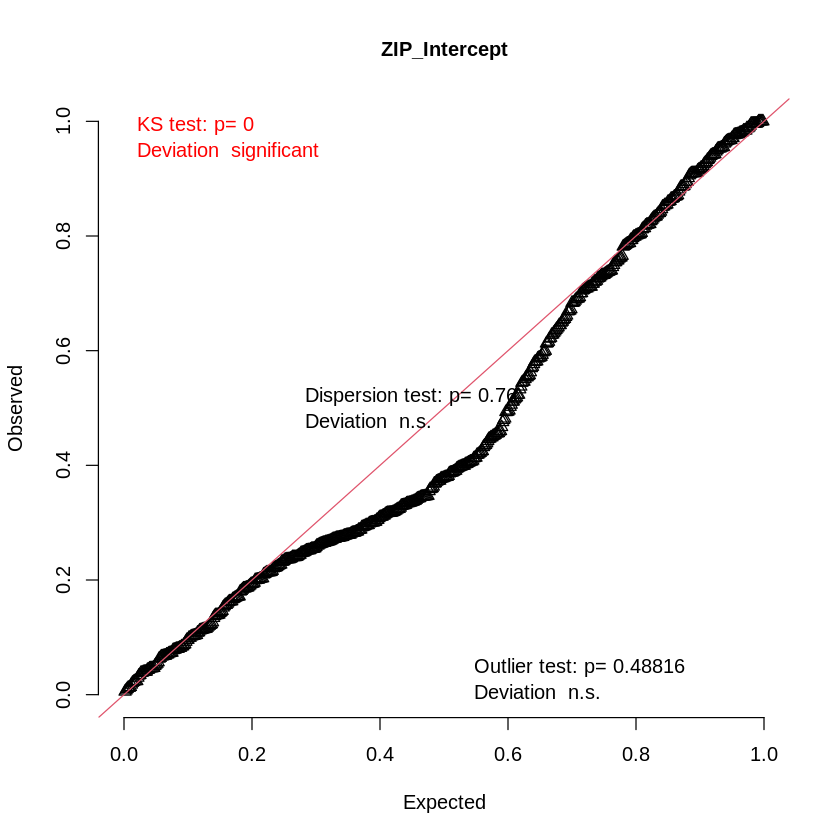

DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details



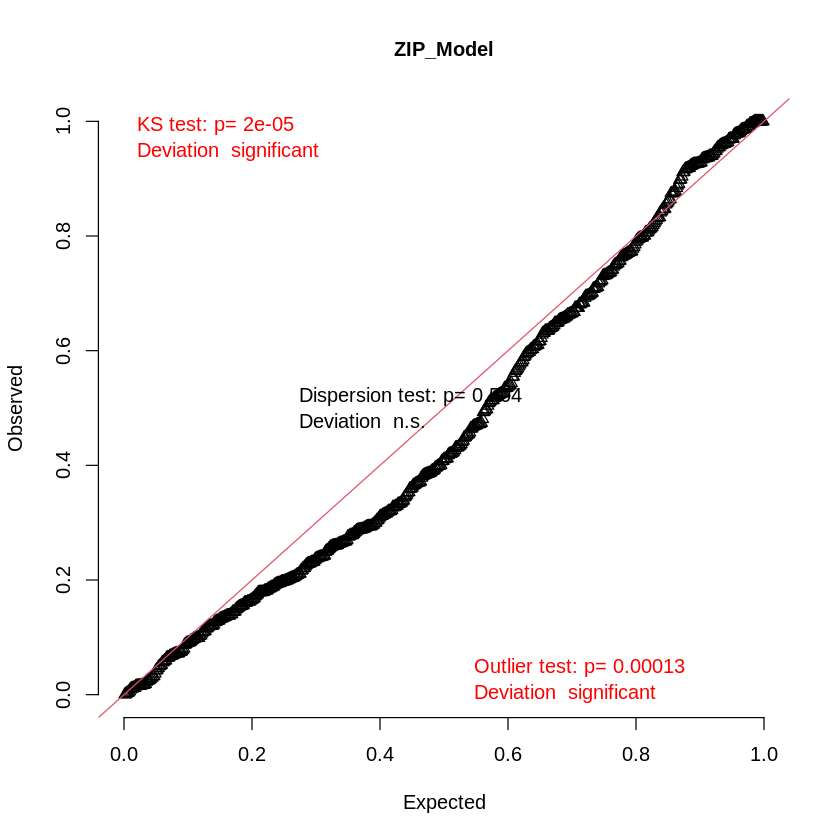

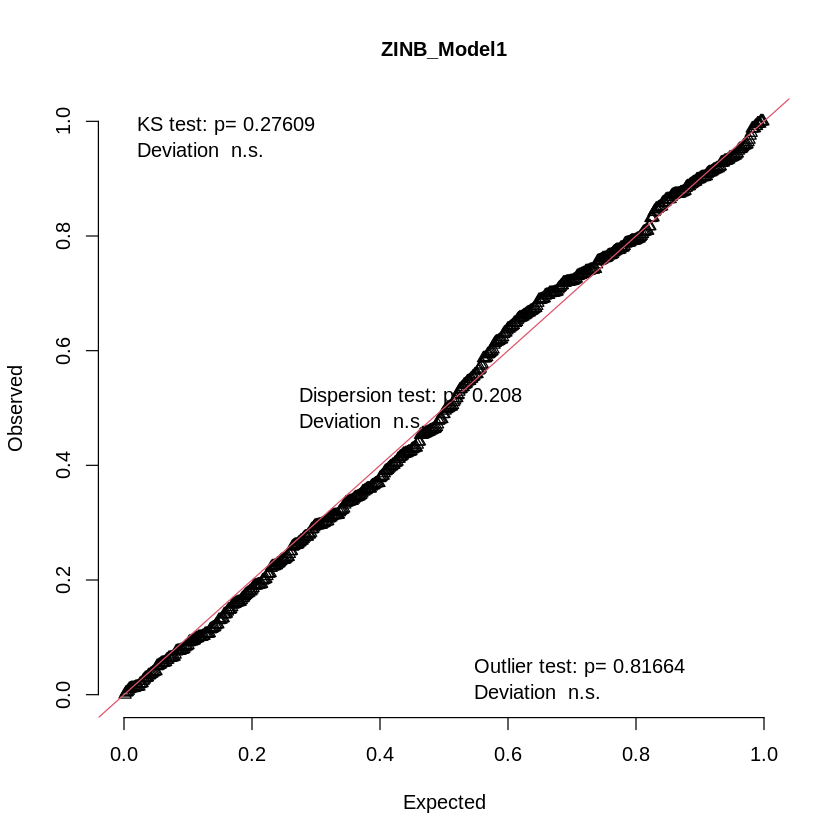

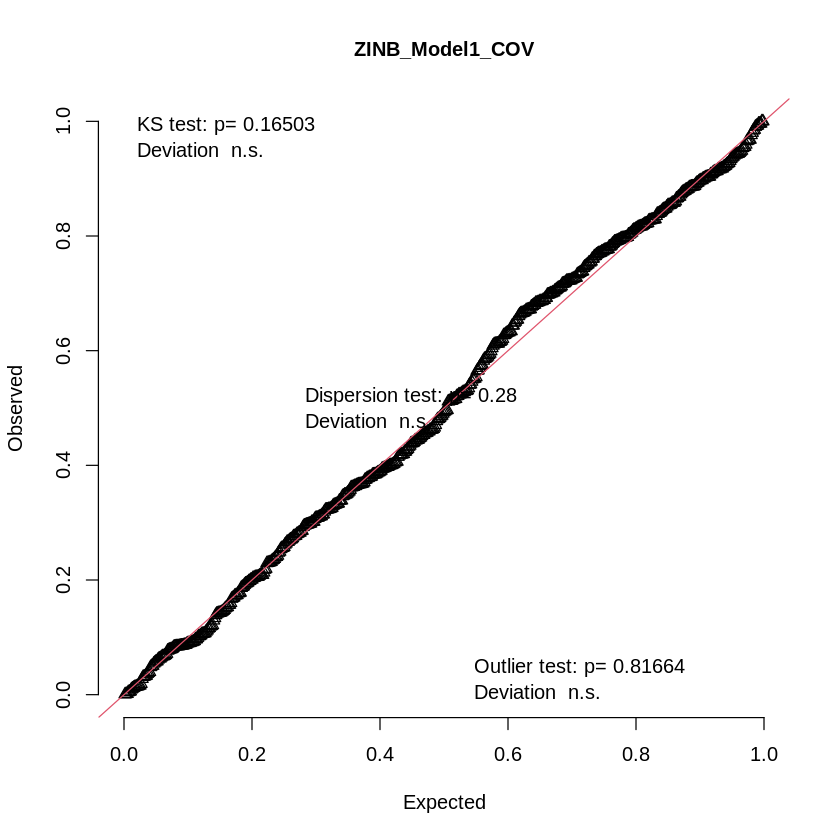

In [26]:
# Reset plotting layout
par(mfrow = c(1, 1))

# Plot QQ-uniform residual diagnostics for each model
plotQQunif(SimDat1, main = "ZIP_Intercept")
plotQQunif(SimDat2, main = "ZIP_Model")
plotQQunif(SimDat3, main = "ZINB_Model1")
plotQQunif(SimDat4, main = "ZINB_Model1_COV")

From these plots we learn:
* residuals are distributed uniformly if model fits well: ks-test and quantile quantile line.
* If the model fits well the residuals of the model will probably be normal distributed.


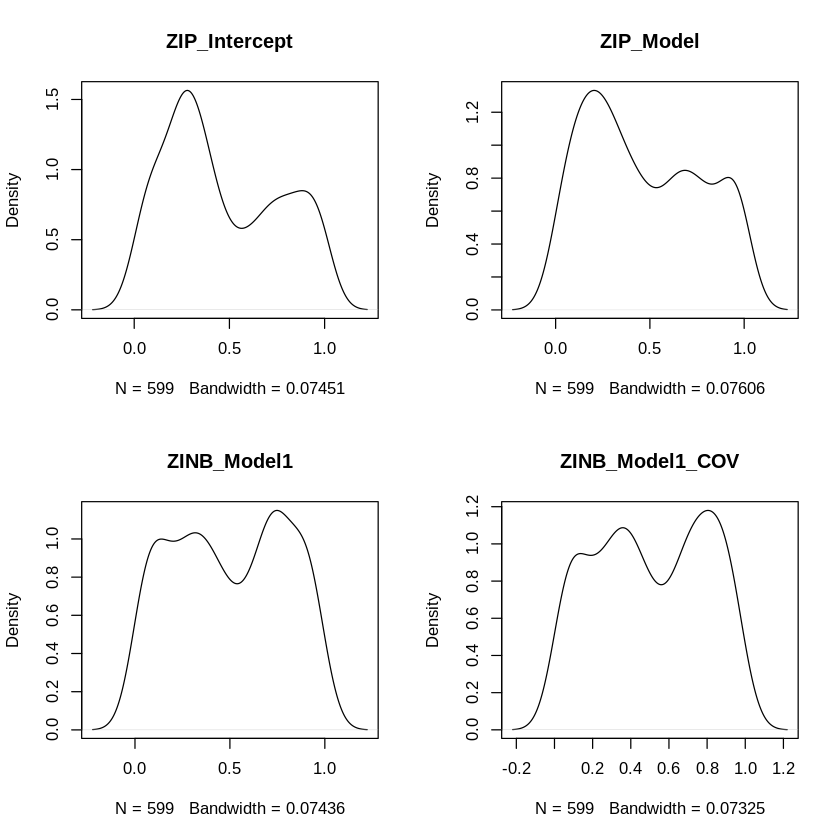

In [27]:
# Plot density of residuals for each model
par(mfrow = c(2, 2))   # set 2x2 layout for density plots

plot(density(residuals(SimDat1)), main = "ZIP_Intercept")
plot(density(residuals(SimDat2)), main = "ZIP_Model")
plot(density(residuals(SimDat3)), main = "ZINB_Model1")
plot(density(residuals(SimDat4)), main = "ZINB_Model1_COV")


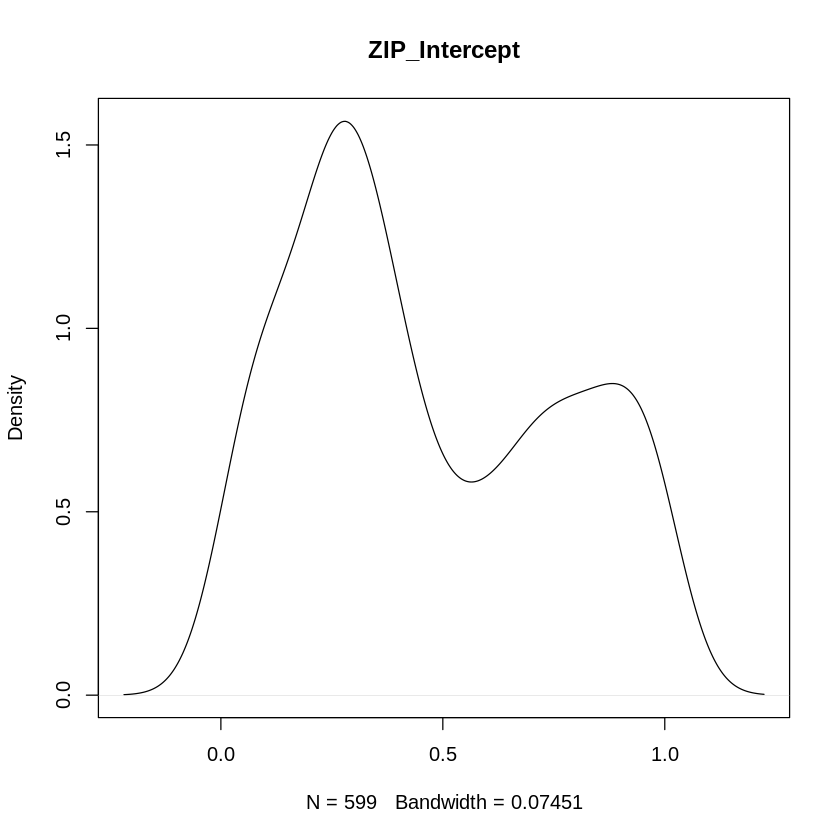

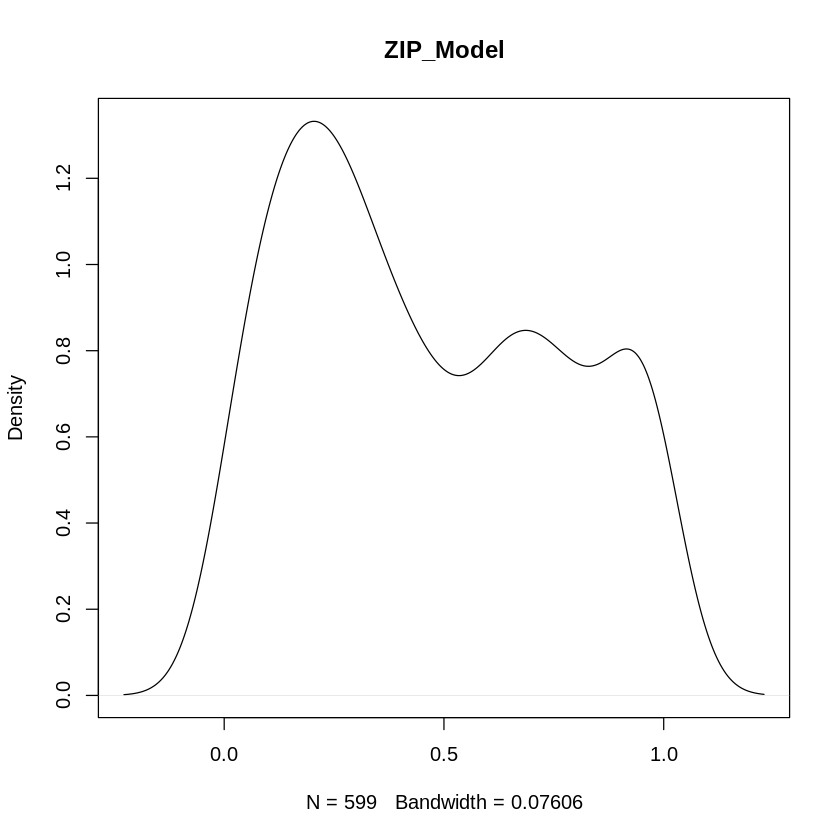

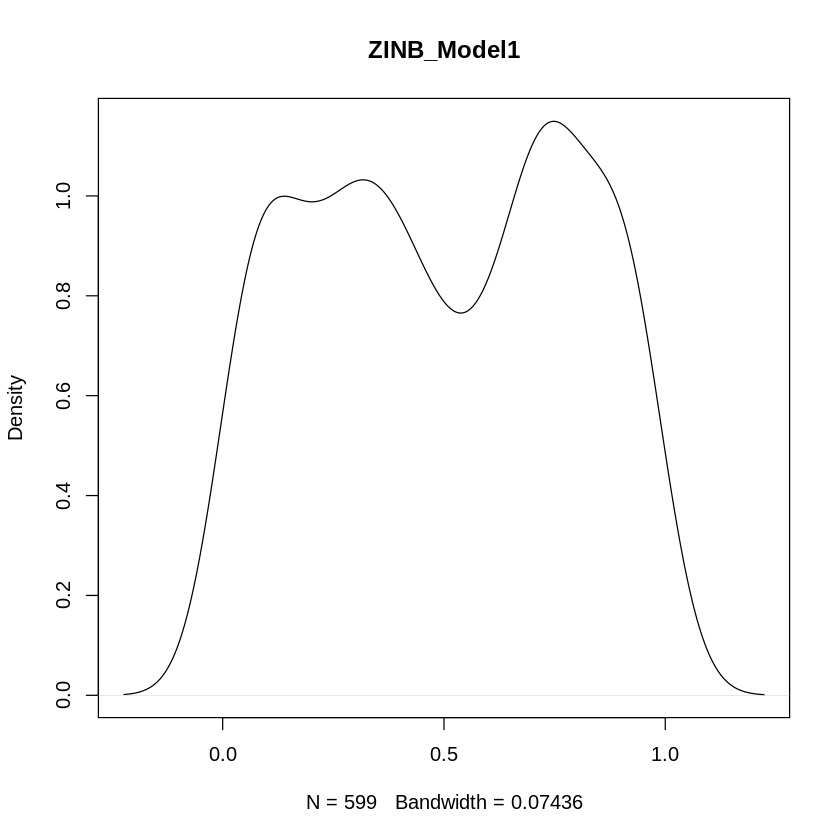

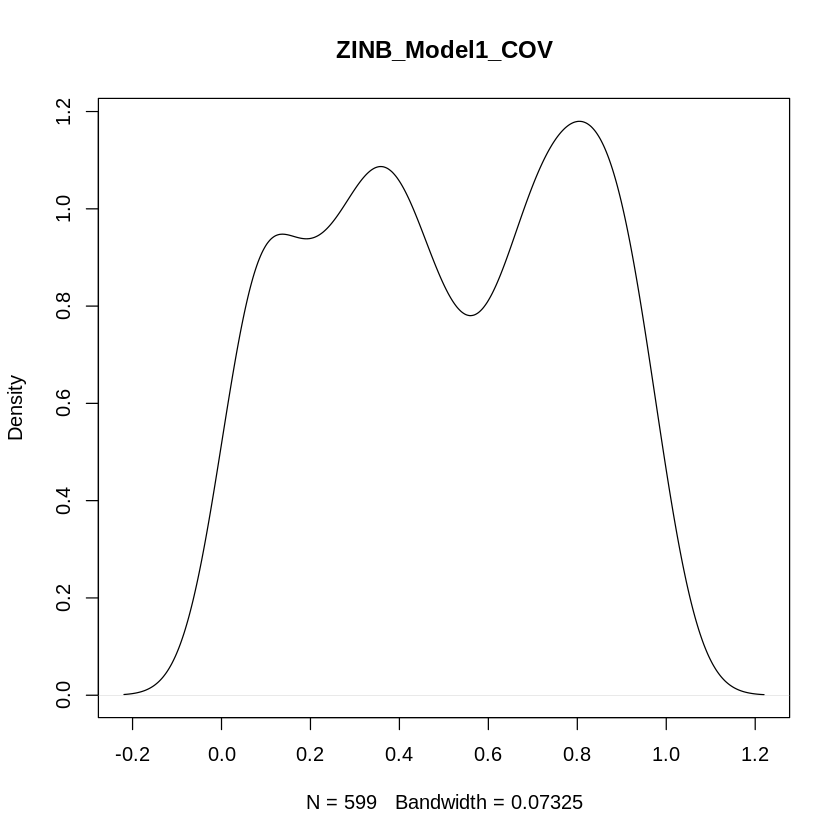

In [28]:
# Reset plotting layout
par(mfrow = c(1, 1))   # back to single plot layout

plot(density(residuals(SimDat1)), main = "ZIP_Intercept")
plot(density(residuals(SimDat2)), main = "ZIP_Model")
plot(density(residuals(SimDat3)), main = "ZINB_Model1")
plot(density(residuals(SimDat4)), main = "ZINB_Model1_COV")

### DHARMA analysis residual quartiles Plot:

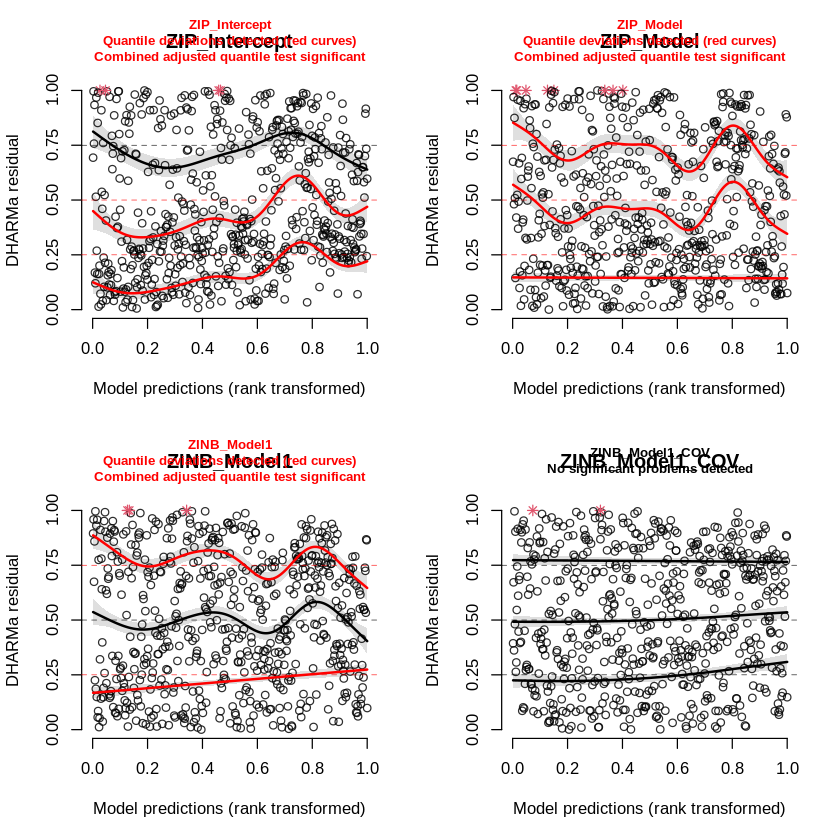

In [29]:
# Plot residuals vs predictors for each model
par(mfrow = c(2, 2))   # set 2x2 layout for residual plots

plotResiduals(SimDat1, main = "ZIP_Intercept")
plotResiduals(SimDat2, main = "ZIP_Model")
plotResiduals(SimDat3, main = "ZINB_Model1")
plotResiduals(SimDat4, main = "ZINB_Model1_COV")

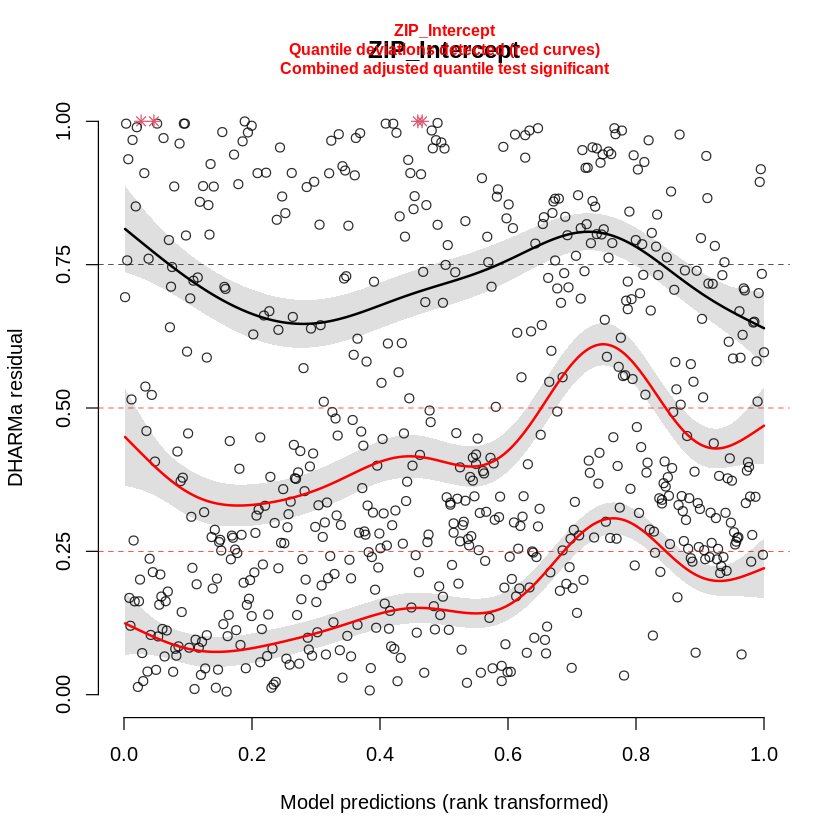

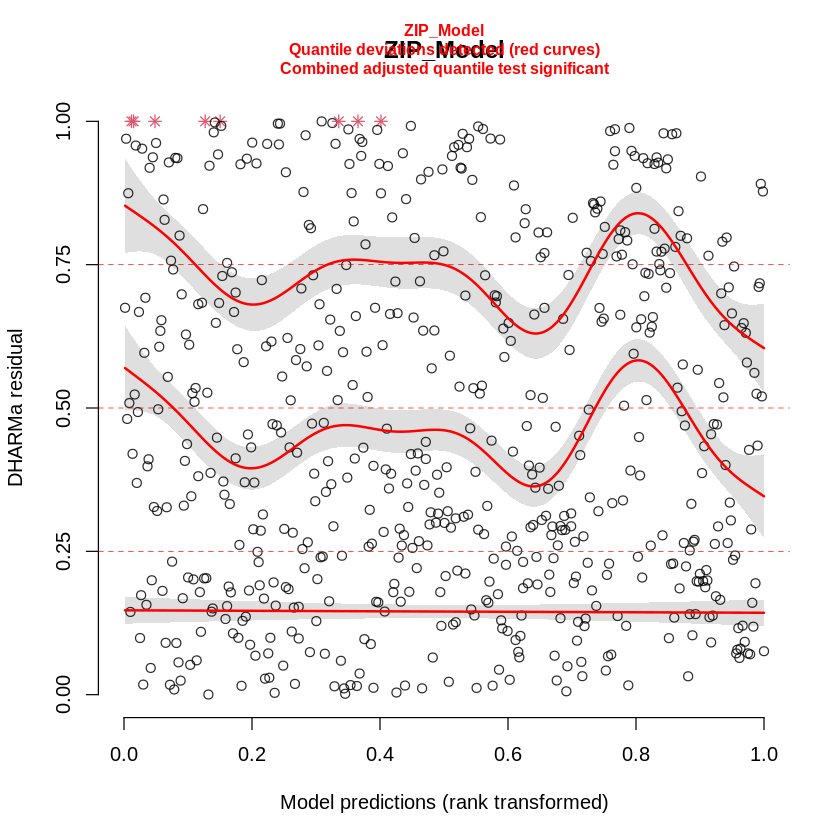

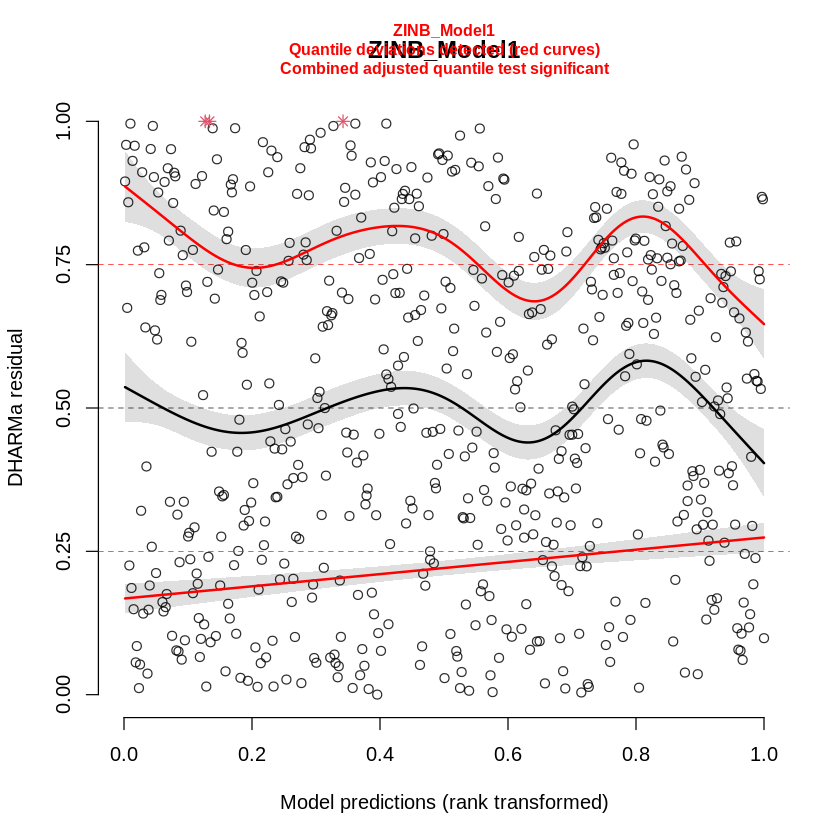

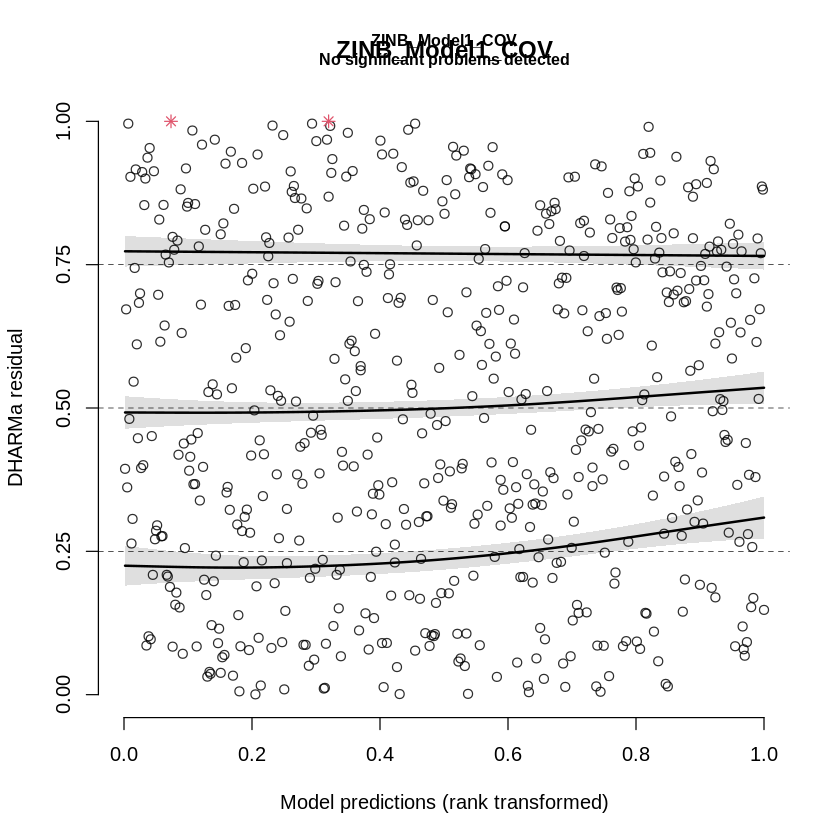

In [30]:
# Reset plotting layout again
par(mfrow = c(1, 1))

plotResiduals(SimDat1, main = "ZIP_Intercept")
plotResiduals(SimDat2, main = "ZIP_Model")
plotResiduals(SimDat3, main = "ZINB_Model1")
plotResiduals(SimDat4, main = "ZINB_Model1_COV")

### Influencial points:
The simulated residual plot of ZINB_Model1_COV gives the best result:
* Not heteroscedastic.
* No non-linearity.
* Only two “outliers”.


In [31]:
# Install the 'car' package (run install only once)
# install.packages("car")

Loading required package: carData

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


using a cluster of 2 cores



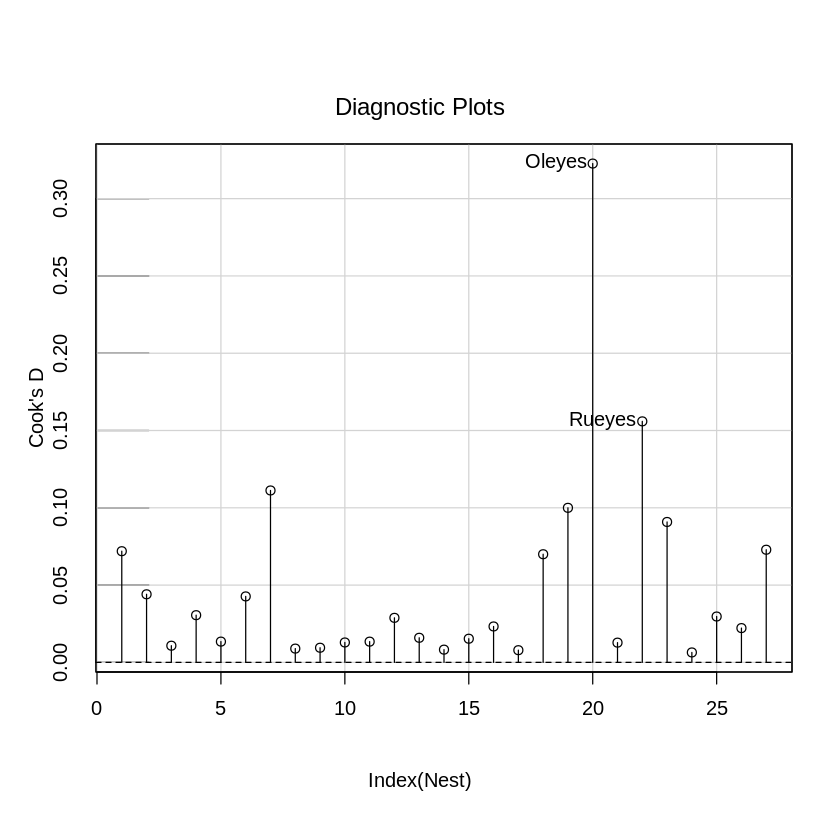

In [32]:
# Load the 'car' package
library(car)

# Source the influence_mixed function provided by glmmTMB
source(system.file("other_methods", "influence_mixed.R", package = "glmmTMB"))

# Compute influence diagnostics for the ZINB model
owls_nb1_influence <- influence_mixed(
  ZINB_Model1_COV,
  groups = "Nest"   # grouping variable for influence analysis
)

# Plot influence index (Cook’s distance)
car::infIndexPlot(
  owls_nb1_influence,
  vars = c("Cook")
)

## 6. ZIPNB model statistics.
### Model comparison AIC and Log Likelihood:


In [33]:
# Compare models using AIC
model_comparison <- AIC(
  Normal_GLM,
  ZIP_Intercept,
  ZIP_Model,
  ZINB_Model1,
  ZINB_Model1_COV
)

# Display results
print(model_comparison)


                df      AIC
Normal_GLM       7 5009.396
ZIP_Intercept    8 4015.635
ZIP_Model       12 3951.228
ZINB_Model1     13 3330.516
ZINB_Model1_COV 14 3327.277


Model ZINB_Model1_COV has lowest AIC and is therefor considered the best Model.

In [34]:
# Likelihood ratio test between ZINB_Model1 and ZIP_Model
anova(
  ZINB_Model1,
  ZIP_Model,
  type = "LRT"
)

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZIP_Model,12,3951.228,4003.971,-1963.614,3927.228,NA,NA,NA
ZINB_Model1,13,3330.516,3387.654,-1652.258,3304.516,622.7127,1,1.922003e-137


In [35]:
# Likelihood ratio test between ZINB_Model1 and ZINB_Model1_COV
anova(
  ZINB_Model1,
  ZINB_Model1_COV,
  type = "LRT"
)

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZINB_Model1,13,3330.516,3387.654,-1652.258,3304.516,NA,NA,NA
ZINB_Model1_COV,14,3327.277,3388.811,-1649.638,3299.277,5.238517,1,0.0220921


### Model Output:

In [36]:
# Inspect detailed summary of ZINB_Model1_COV
summary(ZINB_Model1_COV)

 Family: nbinom1  ( log )
Formula:          
NCalls ~ FT + ArrivalTime + SexParent + BroodSize + (1 | Nest) +  
    FT:SexParent + ArrivalTime:SexParent
Zero inflation:          ~1 + ArrivalTime * FT + SexParent
Data: Owls

      AIC       BIC    logLik -2*log(L)  df.resid 
   3327.3    3388.8   -1649.6    3299.3       585 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 Nest   (Intercept) 0.06065  0.2463  
Number of obs: 599, groups:  Nest, 27

Dispersion parameter for nbinom1 family (): 3.58 

Conditional model:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                3.52284    0.79979   4.405 1.06e-05 ***
FTSatiated                -0.42443    0.14067  -3.017  0.00255 ** 
ArrivalTime               -0.07683    0.03143  -2.444  0.01451 *  
SexParentMale              0.87969    0.97784   0.900  0.36832    
BroodSize                  0.13644    0.05978   2.282  0.02247 *  
FTSatiated:SexParentMale   0.09360    0.16363   0.

### Model simplification:

In [37]:
# Update models by removing interaction terms
## Remove ArrivalTime × SexParent interaction
ZINB_Model1_COV_ARR_Sex <- update(
  ZINB_Model1_COV,
  . ~ . - ArrivalTime:SexParent
)

## Remove FT × SexParent interaction (after removing ArrivalTime × SexParent)
ZINB_Model1_COV_FT_Sex <- update(
  ZINB_Model1_COV_ARR_Sex,
  . ~ . - FT:SexParent
)

In [38]:
# Likelihood ratio tests (model comparisons)

## Compare full model vs reduced (without ArrivalTime × SexParent)
anova(ZINB_Model1_COV, ZINB_Model1_COV_ARR_Sex)


,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZINB_Model1_COV_ARR_Sex,13,3326.180,3383.319,-1650.090,3300.180,NA,NA,NA
ZINB_Model1_COV,14,3327.277,3388.811,-1649.638,3299.277,0.9034522,1,0.3418577


In [39]:
## Compare reduced models (without FT × SexParent vs without ArrivalTime × SexParent)
anova(ZINB_Model1_COV_FT_Sex, ZINB_Model1_COV_ARR_Sex)

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZINB_Model1_COV_FT_Sex,12,3324.648,3377.391,-1650.324,3300.648,NA,NA,NA
ZINB_Model1_COV_ARR_Sex,13,3326.180,3383.319,-1650.090,3300.180,0.4676028,1,0.4940921


In [40]:
# Inspect summary of the reduced model
summary(ZINB_Model1_COV_FT_Sex)

 Family: nbinom1  ( log )
Formula:          
NCalls ~ FT + ArrivalTime + SexParent + BroodSize + (1 | Nest)
Zero inflation:          ~1 + ArrivalTime * FT + SexParent
Data: Owls

      AIC       BIC    logLik -2*log(L)  df.resid 
   3324.6    3377.4   -1650.3    3300.6       587 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 Nest   (Intercept) 0.05797  0.2408  
Number of obs: 599, groups:  Nest, 27

Dispersion parameter for nbinom1 family (): 3.61 

Conditional model:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    4.04093    0.56877   7.105 1.21e-12 ***
FTSatiated    -0.36718    0.09316  -3.942 8.09e-05 ***
ArrivalTime   -0.09934    0.02086  -4.762 1.92e-06 ***
SexParentMale -0.01071    0.07947  -0.135   0.8928    
BroodSize      0.13754    0.05875   2.341   0.0192 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
                       Estimate Std. Error z value Pr(>|z|)  
(Intercept)    

In [41]:
# Fit a final ZIP model with BroodSize as covariate
ZIP_Final <- glmmTMB(
  NCalls ~ FT + ArrivalTime + SexParent + BroodSize + (1 | Nest),
  data      = Owls,
  ziformula = ~ 1 + ArrivalTime + FT + BroodSize,
  family    = nbinom1
)

Object of Class DHARMa with simulated residuals based on 250 simulations with refit = FALSE . See ?DHARMa::simulateResiduals for help. 
 
Scaled residual values: 0.1361184 0.02666421 0.1012155 0.05163669 0.04735338 0.1336185 0.8155375 0.4793756 0.8293068 0.1403217 0.06058492 0.1479826 0.1710306 0.1387612 0.1029764 0.2866172 0.06447175 0.4676179 0.01044771 0.4577139 ...

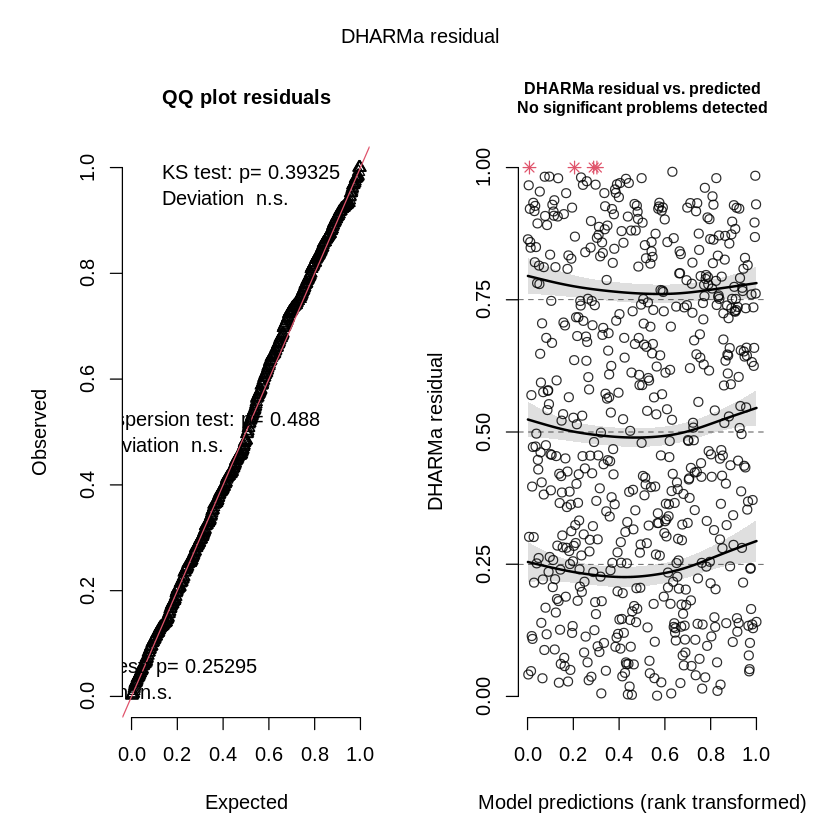

In [42]:
# Residual diagnostics for the final model
simulateResiduals(ZIP_Final, plot = TRUE)

In [43]:
# Inspect summary of final ZIP model with BroodSize as covariate
summary(ZIP_Final)

 Family: nbinom1  ( log )
Formula:          
NCalls ~ FT + ArrivalTime + SexParent + BroodSize + (1 | Nest)
Zero inflation:          ~1 + ArrivalTime + FT + BroodSize
Data: Owls

      AIC       BIC    logLik -2*log(L)  df.resid 
   3302.5    3350.9   -1640.3    3280.5       588 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 Nest   (Intercept) 0.04521  0.2126  
Number of obs: 599, groups:  Nest, 27

Dispersion parameter for nbinom1 family (): 3.35 

Conditional model:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    4.25537    0.53725   7.921 2.36e-15 ***
FTSatiated    -0.33315    0.08418  -3.958 7.57e-05 ***
ArrivalTime   -0.09673    0.01995  -4.849 1.24e-06 ***
SexParentMale  0.02691    0.07547   0.357    0.721    
BroodSize      0.07476    0.04834   1.546    0.122    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.79733    

### Model Output: Random effect table
Lets look at the different parts of the output.
* Random effect table
* Conditional model table
* Zero -inflation table

Random effect table


In [44]:
# Inspect variance–covariance components of the final model
summary(ZIP_Final)$varcor


Conditional model:
 Groups Name        Std.Dev.
 Nest   (Intercept) 0.21263 

In [45]:
# Extract confidence interval for the random intercept (Nest)
confint(ZIP_Final)["cond.Std.Dev.(Intercept)|Nest", ]

2.5 %    97.5 %  Estimate 
0.1266064 0.3571037 0.2126302

### Model Output: Conditional model

In [46]:
# Inspect conditional (fixed effect) coefficients
cond_coefs <- summary(ZIP_Final)$coefficients$cond

# Round coefficients for readability
round(cond_coefs, 4)

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),4.2554,0.5372,7.9206,0.0000
FTSatiated,-0.3332,0.0842,-3.9577,0.0001
ArrivalTime,-0.0967,0.0199,-4.8492,0.0000
SexParentMale,0.0269,0.0755,0.3565,0.7214
BroodSize,0.0748,0.0483,1.5465,0.1220


In [47]:
# Exponentiate the estimates (to interpret as rate ratios)
exp_estimates <- exp(cond_coefs[, 1])

# Round exponentiated values
round(exp_estimates, 3)

(Intercept)    FTSatiated   ArrivalTime SexParentMale     BroodSize 
       70.483         0.717         0.908         1.027         1.078

* Expected number of calls for FT = Satiated is 0.64 × the expected number for the baseline (FT = Deprived), holding other covariates constant.
* Expected number of calls rate of change is 0.9 per unit (decrease)


### Model Output: Zero-Inflation model

In [48]:
# Extract zero-inflation (zi) coefficients
zi_coefs <- summary(ZIP_Final)$coefficients$zi

# Round coefficients for readability
round(zi_coefs, 5)

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-3.79733,1.64462,-2.30893,0.02095
ArrivalTime,0.15964,0.06271,2.54563,0.01091
FTSatiated,1.62840,0.25697,6.33705,0.00000
BroodSize,-0.54724,0.10882,-5.02886,0.00000


In [49]:
# Exponentiate the estimates (to interpret on probability scale)
exp_zi_estimates <- exp(zi_coefs[, 1])

# Round exponentiated values
round(exp_zi_estimates, 3)

(Intercept) ArrivalTime  FTSatiated   BroodSize 
      0.022       1.173       5.096       0.579

* (Intercept) = 0.022, the baseline odds of being a structural zero are 0.022, i.e. a baseline probability of about 0.022 / (1 + 0.022) ≈ 2.1%.

* ArrivalTime = 1.173, for a 1-unit increase in ArrivalTime, the odds of being a structural zero are multiplied by 1.173 (a +17.3% change in odds), holding other variables constant. (Don’t say “1.173 × ArrivalTime”; it’s 1.173× the odds per 1 unit.)

* BroodSize = 0.579, for a 1-unit increase in BroodSize, the odds are multiplied by 0.579 (a −42.1% change in odds), holding others constant. (Your “42.2% decrease” is fine to the rounding you used.)

* FTSatiated = 5.096, relative to the reference level of FTSatiated, the odds of being a structural zero are 5.096× higher—i.e., about a +409.6% increase in odds, not 501%. (Say “times higher odds,” not “difference of 5.096 in odds.”)


### Final visualisation:
Code from ChatGPT


### BUT
Be critical.


[1] 123 425

[1] 123 519

[1] 519 123

[1] 519 123

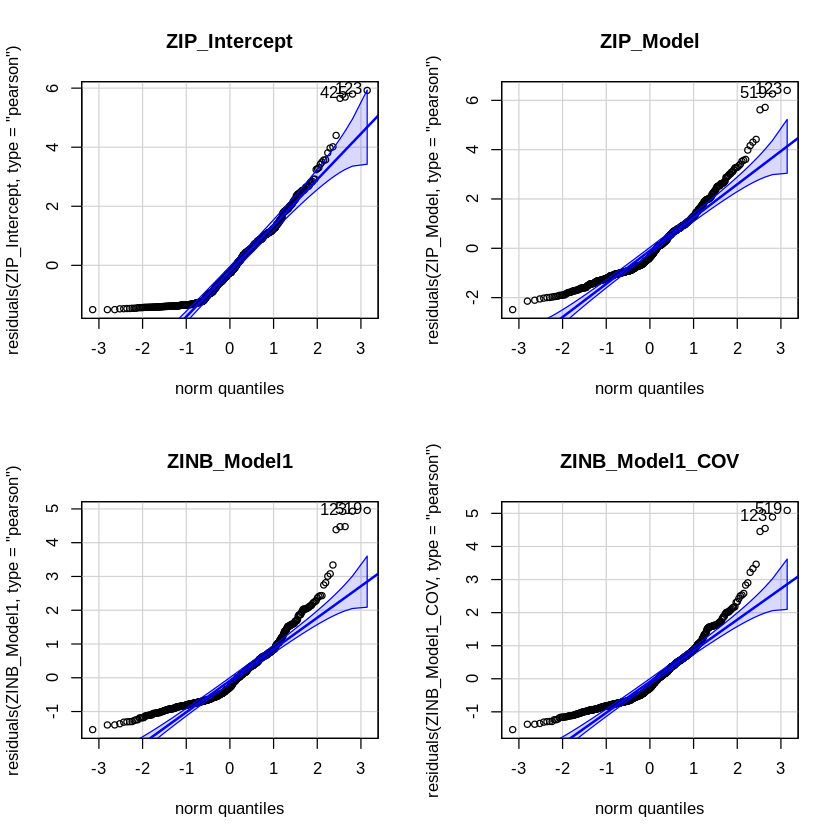

In [50]:
# QQ plots of Pearson residuals for each model
par(mfrow = c(2, 2))   # set 2x2 layout for QQ plots

car::qqPlot(residuals(ZIP_Intercept, type = "pearson"), main = "ZIP_Intercept")
car::qqPlot(residuals(ZIP_Model, type = "pearson"), main = "ZIP_Model")
car::qqPlot(residuals(ZINB_Model1, type = "pearson"), main = "ZINB_Model1")
car::qqPlot(residuals(ZINB_Model1_COV, type = "pearson"), main = "ZINB_Model1_COV")

[1] 123 425

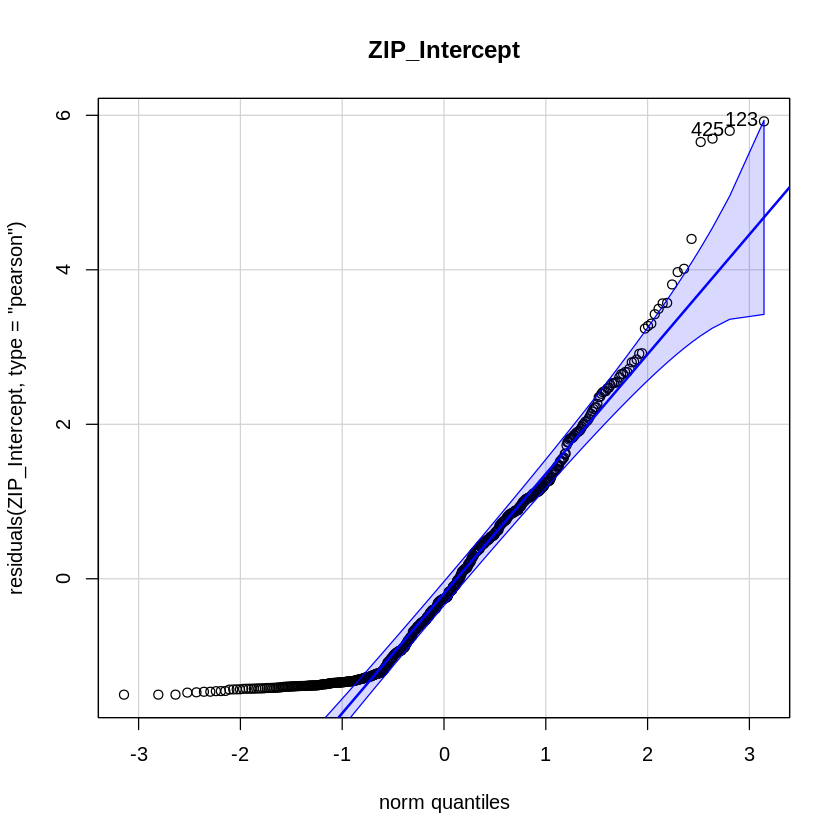

[1] 123 519

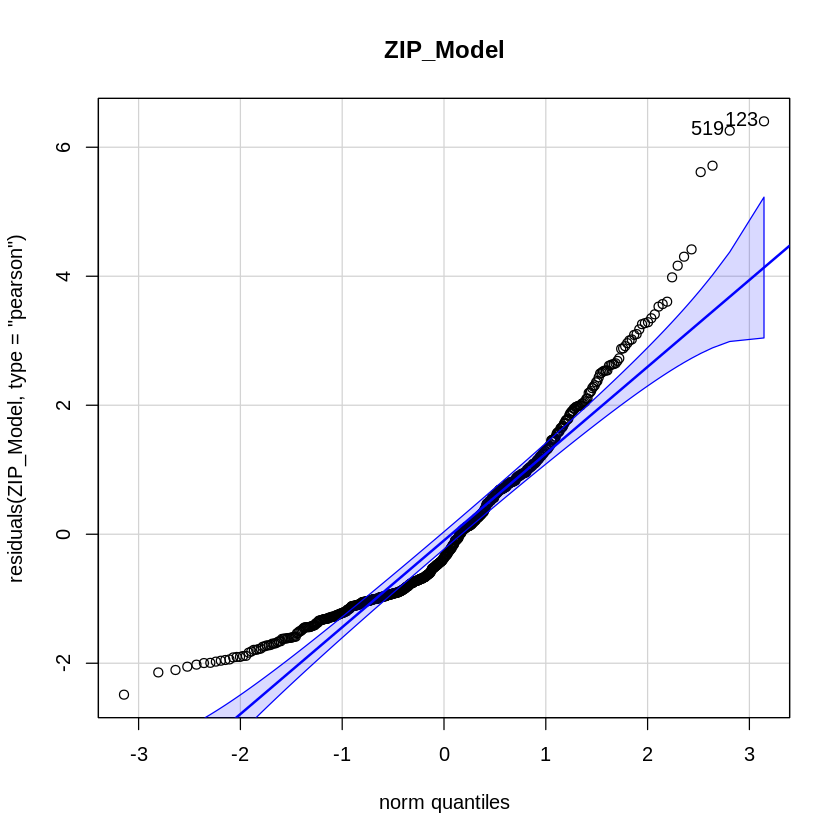

[1] 519 123

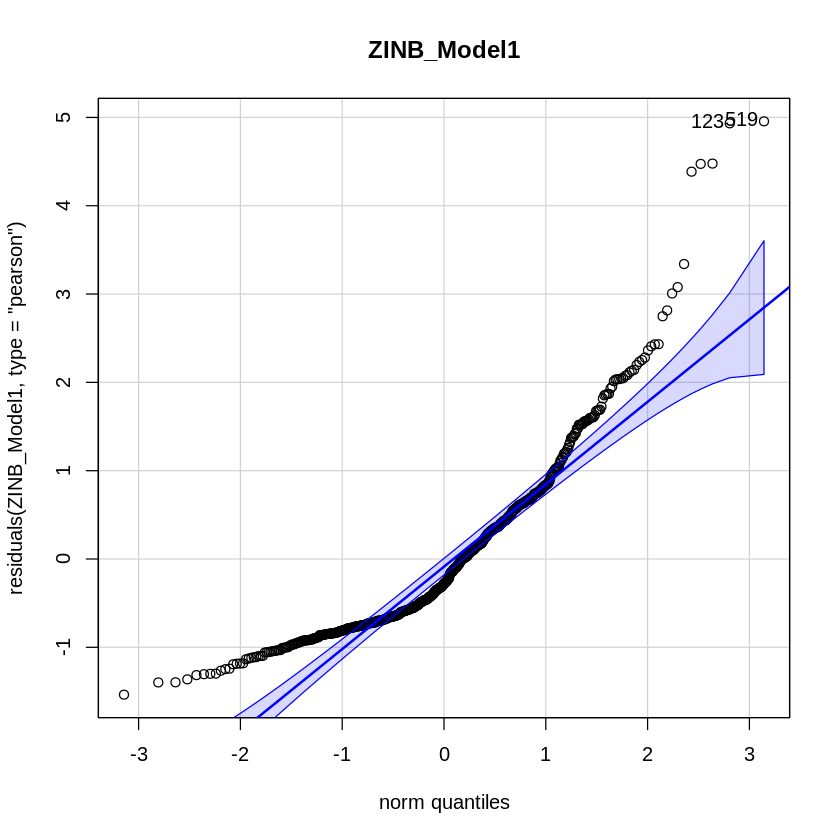

[1] 519 123

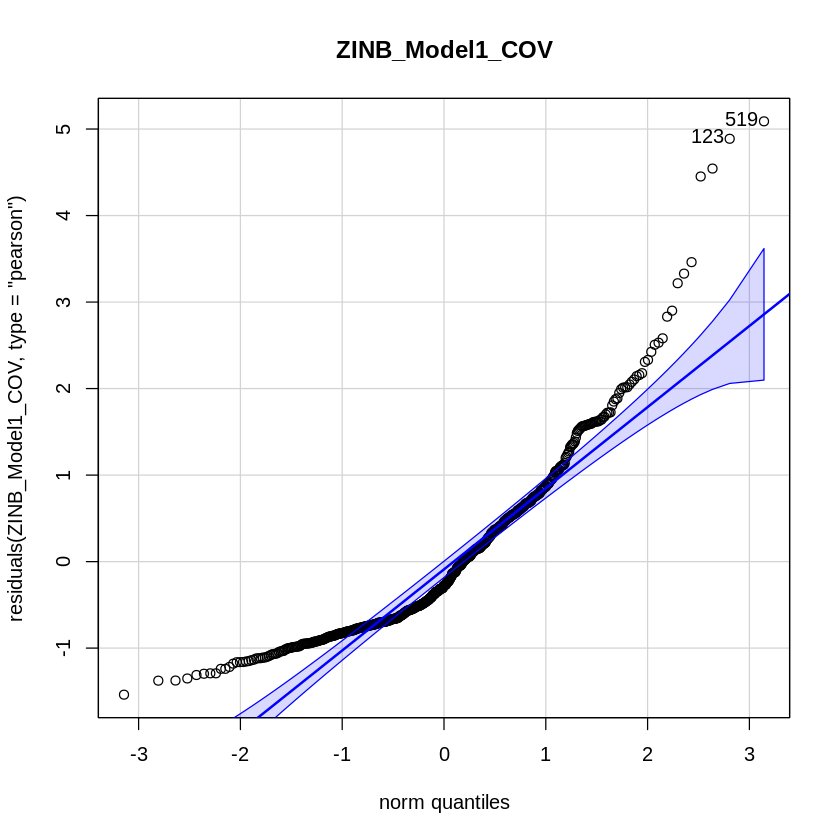

In [51]:
# Reset plotting layout
par(mfrow = c(1, 1))

car::qqPlot(residuals(ZIP_Intercept, type = "pearson"), main = "ZIP_Intercept")
car::qqPlot(residuals(ZIP_Model, type = "pearson"), main = "ZIP_Model")
car::qqPlot(residuals(ZINB_Model1, type = "pearson"), main = "ZINB_Model1")
car::qqPlot(residuals(ZINB_Model1_COV, type = "pearson"), main = "ZINB_Model1_COV")

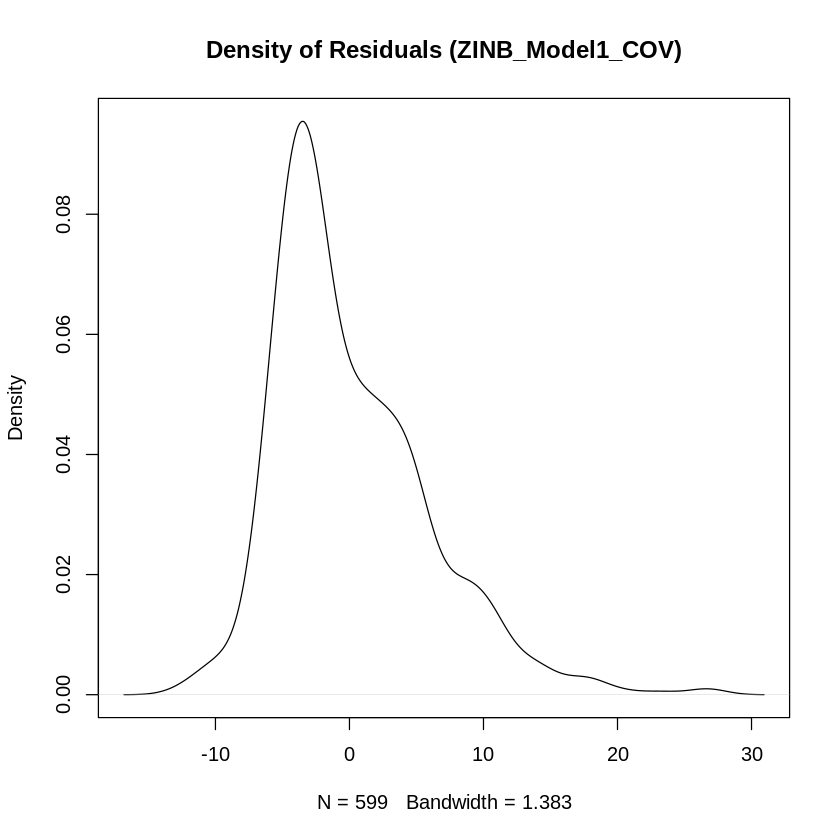

In [52]:
# Density plot of residuals for ZINB_Model1_COV
plot(
  density(residuals(ZINB_Model1_COV)),
  main = "Density of Residuals (ZINB_Model1_COV)"
)

<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...!

Ms.MRUNALINI (Data Science Trainer)